
MNIST: Total 50 Samples (5/class)

>>> Seed 0
 Epoch 25 finished.
 Epoch 50 finished.
 Epoch 75 finished.
 Epoch 100 finished.
 Seed 0 Final | Spec T3: 0.715 | Spat T3: 0.539

>>> Seed 1
 Epoch 25 finished.
 Epoch 50 finished.
 Epoch 75 finished.
 Epoch 100 finished.
 Seed 1 Final | Spec T3: 0.732 | Spat T3: 0.578

>>> Seed 2
 Epoch 25 finished.
 Epoch 50 finished.
 Epoch 75 finished.
 Epoch 100 finished.
 Seed 2 Final | Spec T3: 0.691 | Spat T3: 0.590

>>> Seed 3
 Epoch 25 finished.
 Epoch 50 finished.
 Epoch 75 finished.
 Epoch 100 finished.
 Seed 3 Final | Spec T3: 0.726 | Spat T3: 0.564

>>> Seed 4
 Epoch 25 finished.
 Epoch 50 finished.
 Epoch 75 finished.
 Epoch 100 finished.
 Seed 4 Final | Spec T3: 0.755 | Spat T3: 0.550

MNIST: Total 200 Samples (20/class)

>>> Seed 0
 Epoch 25 finished.
 Epoch 50 finished.
 Epoch 75 finished.
 Epoch 100 finished.
 Seed 0 Final | Spec T3: 0.837 | Spat T3: 0.718

>>> Seed 1
 Epoch 25 finished.
 Epoch 50 finished.
 Epoch 75 finished.
 Epoch 100

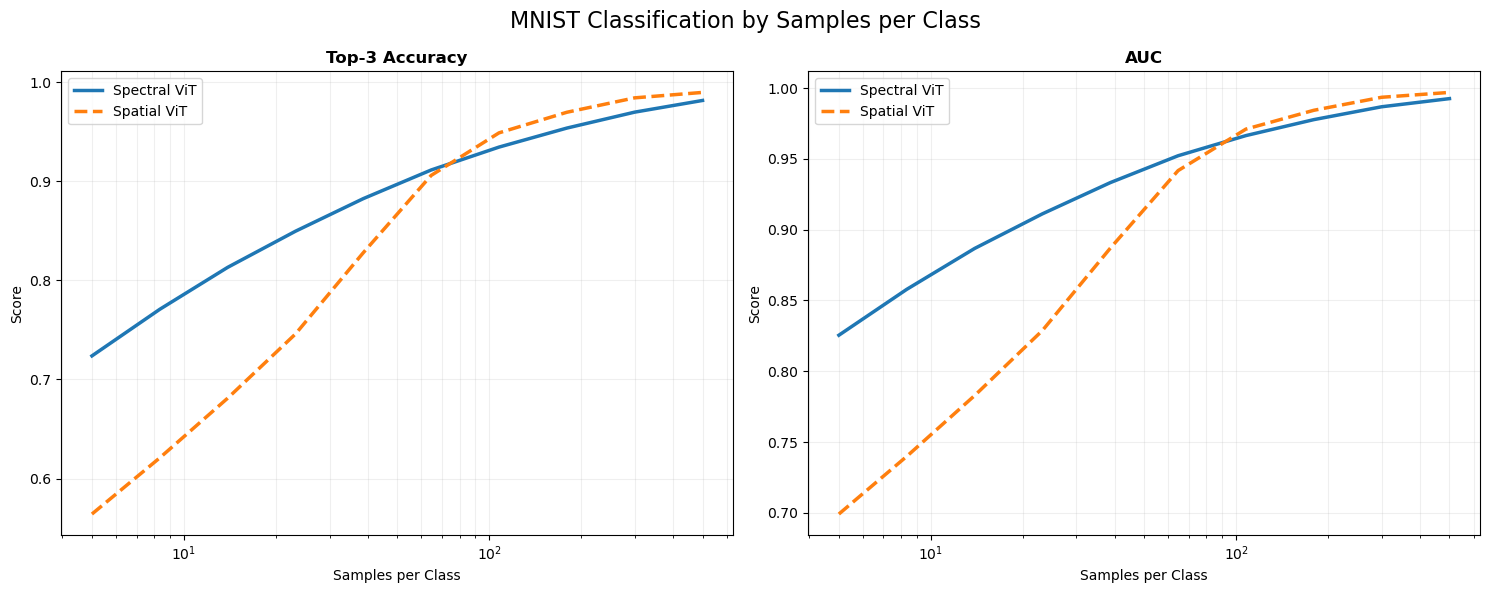

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from scipy.interpolate import PchipInterpolator
from networks import MultiClassSpatialViT, MultiClassSpectralViT
from util import get_stratified_subset, smooth_curve, compute_multiclass_metrics

# GPU setup
device = torch.device("cuda:7" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

# Data preparation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_full = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_full = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Parameters (from previous numerical simulation)
TARGET_PCA_COMPONENTS = 16 
N_SEEDS = 5
PER_CLASS_SIZES = [5, 20, 100, 500] 
EPOCHS = 100 
BATCH_SIZE = 128

results_list = []

for per_class in PER_CLASS_SIZES:
    total_n = per_class * 10
    print(f"\n{'='*65}\nMNIST: Total {total_n} Samples ({per_class}/class)\n{'='*65}")
    
    for seed in range(N_SEEDS):
        torch.manual_seed(seed)
        np.random.seed(seed)
        print(f"\n>>> Seed {seed}")
        
        # Data preparation
        tr_imgs, tr_labels = get_stratified_subset(train_full, per_class)
        te_imgs = torch.stack([test_full[i][0] for i in range(len(test_full))])
        te_labels = test_full.targets

        X_tr_flat = tr_imgs.view(tr_imgs.size(0), -1).numpy()
        X_te_flat = te_imgs.view(te_imgs.size(0), -1).numpy()
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr_flat)
        X_te_scaled = scaler.transform(X_te_flat)
        
        n_comp = min(TARGET_PCA_COMPONENTS, X_tr_flat.shape[0])
        pca = PCA(n_components=n_comp)
        X_tr_pca = torch.tensor(pca.fit_transform(X_tr_scaled), dtype=torch.float32)
        X_te_pca = torch.tensor(pca.transform(X_te_scaled), dtype=torch.float32)
        actual_pca_dim = X_tr_pca.shape[1]

        train_loader = DataLoader(TensorDataset(tr_imgs, X_tr_pca, tr_labels), batch_size=BATCH_SIZE, shuffle=True)
        eval_loader = DataLoader(TensorDataset(te_imgs, X_te_pca, te_labels), batch_size=512)
        
        # Models
        m_spec = MultiClassSpectralViT(n_inputs=actual_pca_dim).to(device)
        m_spat = MultiClassSpatialViT().to(device)
        opt = optim.AdamW(list(m_spec.parameters()) + list(m_spat.parameters()), lr=1e-3, weight_decay=0.01)
        
        # Training
        for epoch in range(EPOCHS):
            m_spec.train(); m_spat.train()
            for b_img, b_pca, b_y in train_loader:
                b_img, b_pca, b_y = b_img.to(device), b_pca.to(device), b_y.to(device)
                opt.zero_grad()
                loss = F.cross_entropy(m_spec(b_pca), b_y) + F.cross_entropy(m_spat(b_img), b_y)
                loss.backward()
                opt.step()

            if (epoch + 1) % 25 == 0:
                print(f" Epoch {epoch+1:2d} finished.")

        # Evaluation
        m_spec.eval(); m_spat.eval()
        all_p_s, all_p_p = [], []
        with torch.no_grad():
            for b_img, b_pca, _ in eval_loader:
                b_img, b_pca = b_img.to(device), b_pca.to(device)
                all_p_s.append(F.softmax(m_spec(b_pca), dim=1).cpu())
                all_p_p.append(F.softmax(m_spat(b_img), dim=1).cpu())
        
        ps = torch.cat(all_p_s).numpy()
        pp = torch.cat(all_p_p).numpy()
        y_true = te_labels.numpy()

        ms, mp = compute_multiclass_metrics(ps, y_true), compute_multiclass_metrics(pp, y_true)

        results_list.append({
            'per_class': per_class,
            'Spec_T1': ms['T1'], 'Spat_T1': mp['T1'],
            'Spec_T3': ms['T3'], 'Spat_T3': mp['T3'],
            'Spec_T5': ms['T5'], 'Spat_T5': mp['T5'], 
            'Spec_AUC': ms['AUC'], 'Spat_AUC': mp['AUC'],
        })
        print(f" Seed {seed} Final | Spec T3: {ms['T3']:.3f} | Spat T3: {mp['T3']:.3f}")

# Plotting
df = pd.DataFrame(results_list).groupby('per_class').mean().reset_index()
print("\n--- Final MNIST Results Table ---")
print(df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
metrics_plot = [('T3', 'Top-3 Accuracy'), ('AUC', 'AUC')]

x_vals = df['per_class'].values
for i, (m_id, m_name) in enumerate(metrics_plot):
    ax = axes[i]
    xp, yp = smooth_curve(x_vals, df[f'Spec_{m_id}'].values,10)
    ax.plot(xp, yp, label='Spectral ViT', lw=2.5, linestyle='-')
    xs, ys = smooth_curve(x_vals, df[f'Spat_{m_id}'].values,10)
    ax.plot(xs, ys, lw=2.5, ls='--', label='Spatial ViT')
    
    ax.set_title(m_name, fontweight='bold')
    ax.set_xscale('log')
    ax.set_xlabel('Samples per Class')
    ax.set_ylabel('Score')
    ax.grid(True, which='both', alpha=0.2)
    ax.legend()

plt.suptitle('MNIST Classification by Samples per Class', fontsize=16)
plt.tight_layout()
plt.show()


Testing N_COMPONENTS = 4

>>> Seed 0
 N_Comp: 4 | Seed 0 Final | T3: 0.943 | AUC: 0.955

>>> Seed 1
 N_Comp: 4 | Seed 1 Final | T3: 0.943 | AUC: 0.953

>>> Seed 2
 N_Comp: 4 | Seed 2 Final | T3: 0.941 | AUC: 0.951

>>> Seed 3
 N_Comp: 4 | Seed 3 Final | T3: 0.944 | AUC: 0.953

>>> Seed 4
 N_Comp: 4 | Seed 4 Final | T3: 0.940 | AUC: 0.952

Testing N_COMPONENTS = 8

>>> Seed 0
 N_Comp: 8 | Seed 0 Final | T3: 0.977 | AUC: 0.987

>>> Seed 1
 N_Comp: 8 | Seed 1 Final | T3: 0.979 | AUC: 0.987

>>> Seed 2
 N_Comp: 8 | Seed 2 Final | T3: 0.975 | AUC: 0.985

>>> Seed 3
 N_Comp: 8 | Seed 3 Final | T3: 0.977 | AUC: 0.986

>>> Seed 4
 N_Comp: 8 | Seed 4 Final | T3: 0.974 | AUC: 0.985

Testing N_COMPONENTS = 16

>>> Seed 0
 N_Comp: 16 | Seed 0 Final | T3: 0.977 | AUC: 0.992

>>> Seed 1
 N_Comp: 16 | Seed 1 Final | T3: 0.980 | AUC: 0.991

>>> Seed 2
 N_Comp: 16 | Seed 2 Final | T3: 0.978 | AUC: 0.991

>>> Seed 3
 N_Comp: 16 | Seed 3 Final | T3: 0.981 | AUC: 0.991

>>> Seed 4
 N_Comp: 16 | Seed 4 Fi

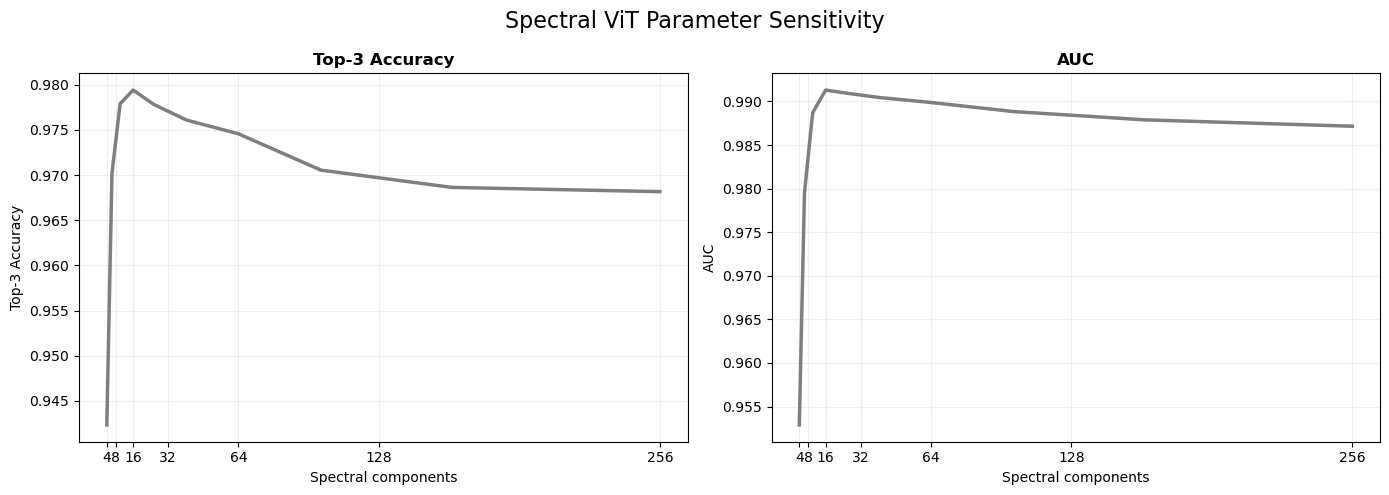

In [2]:
# ==========================================
# N_COMPONENT Parameter Sensitivity (Spectral ViT Only, Full Dataset)
# ==========================================

# Parameters for sensitivity analysis
N_COMPONENT_VALUES = [4, 8, 16, 32, 64, 128, 256]
N_SEEDS_SENSITIVITY = 5
FULL_PER_CLASS = 500  # Full dataset size per class (500 * 10 = 5000 total training samples)
EPOCHS_SENSITIVITY = 50
BATCH_SIZE = 128

sensitivity_results = []

for n_comp_target in N_COMPONENT_VALUES:
    print(f"\n{'='*65}\nTesting N_COMPONENTS = {n_comp_target}\n{'='*65}")
    
    for seed in range(N_SEEDS_SENSITIVITY):
        torch.manual_seed(seed)
        np.random.seed(seed)
        print(f"\n>>> Seed {seed}")
        
        # Data preparation (Full dataset size)
        tr_imgs, tr_labels = get_stratified_subset(train_full, FULL_PER_CLASS)
        te_imgs = torch.stack([test_full[i][0] for i in range(len(test_full))])
        te_labels = test_full.targets

        X_tr_flat = tr_imgs.view(tr_imgs.size(0), -1).numpy()
        X_te_flat = te_imgs.view(te_imgs.size(0), -1).numpy()
        
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr_flat)
        X_te_scaled = scaler.transform(X_te_flat)
        
        # Apply current N_COMPONENT value
        n_comp = min(n_comp_target, X_tr_flat.shape[0], X_tr_flat.shape[1])
        pca = PCA(n_components=n_comp)
        X_tr_pca = torch.tensor(pca.fit_transform(X_tr_scaled), dtype=torch.float32)
        X_te_pca = torch.tensor(pca.transform(X_te_scaled), dtype=torch.float32)
        actual_pca_dim = X_tr_pca.shape[1]

        train_loader = DataLoader(TensorDataset(X_tr_pca, tr_labels), batch_size=BATCH_SIZE, shuffle=True)
        eval_loader = DataLoader(TensorDataset(X_te_pca, te_labels), batch_size=512)
        
        # Spectral ViT model only
        m_spec = MultiClassSpectralViT(n_inputs=actual_pca_dim).to(device)
        opt = optim.AdamW(m_spec.parameters(), lr=1e-3, weight_decay=0.01)
        
        # Training loop
        for epoch in range(EPOCHS_SENSITIVITY):
            m_spec.train()
            for b_pca, b_y in train_loader:
                b_pca, b_y = b_pca.to(device), b_y.to(device)
                opt.zero_grad()
                loss = F.cross_entropy(m_spec(b_pca), b_y)
                loss.backward()
                opt.step()

        # Evaluation
        m_spec.eval()
        all_p_s = []
        with torch.no_grad():
            for b_pca, _ in eval_loader:
                b_pca = b_pca.to(device)
                all_p_s.append(F.softmax(m_spec(b_pca), dim=1).cpu())
        
        ps = torch.cat(all_p_s).numpy()
        y_true = te_labels.numpy()
        ms = compute_multiclass_metrics(ps, y_true)

        sensitivity_results.append({
            'n_components': actual_pca_dim,
            'Spec_T1': ms['T1'],
            'Spec_T3': ms['T3'],
            'Spec_T5': ms['T5'],
            'Spec_AUC': ms['AUC'],
        })
        print(f" N_Comp: {actual_pca_dim} | Seed {seed} Final | T3: {ms['T3']:.3f} | AUC: {ms['AUC']:.3f}")

# Sensitivity Results Processing & Plotting
df_sens = pd.DataFrame(sensitivity_results).groupby('n_components').mean().reset_index()
print("\n--- N_COMPONENT Sensitivity Results Table ---")
print(df_sens.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics_plot = [('T3', 'Top-3 Accuracy'), ('AUC', 'AUC')]

x_vals = df_sens['n_components'].values
for i, (m_id, m_name) in enumerate(metrics_plot):
    ax = axes[i]
    y_vals = df_sens[f'Spec_{m_id}'].values
    xs, ys = smooth_curve(x_vals, y_vals, n=10)
    ax.plot(xs, ys, lw=2.5, color='tab:gray', label='Spectral ViT')
    ax.set_title(f'{m_name}', fontweight='bold')
    ax.set_xlabel('Spectral components')
    ax.set_ylabel(m_name)
    ax.grid(True, which='both', alpha=0.2)
    ax.set_xticks(x_vals)

plt.suptitle('Spectral ViT Parameter Sensitivity', fontsize=16)
plt.tight_layout()
plt.show()